In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
%matplotlib inline

# Load data
processed_path = Path('../data/processed')
files = sorted(processed_path.glob('*.parquet'))
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(f"Total records: {len(df):,}")
print(f"Date range: {df['FlightDate'].min()} to {df['FlightDate'].max()}")

Total records: 38,761,873
Date range: 2019-01-01 00:00:00 to 2024-12-31 00:00:00


In [7]:
# Load all processed files
processed_path = Path('../data/processed')
files = sorted(processed_path.glob('*.parquet'))

# Load and combine
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(f"Total records: {len(df):,}")
print(f"Date range: {df['FlightDate'].min()} to {df['FlightDate'].max()}")
print(f"Columns: {df.shape[1]}")

Total records: 38,761,873
Date range: 2019-01-01 00:00:00 to 2024-12-31 00:00:00
Columns: 38


In [8]:
# Basic info
print("=== DATASET OVERVIEW ===")
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nData types:\n{df.dtypes}")

=== DATASET OVERVIEW ===

Shape: (38761873, 38)

Missing values:
Flight_Number_Reporting_Airline           1
Tail_Number                          258377
DepTime                              864975
ArrTime                              894329
CancellationCode                   37877310
CRSElapsedTime                          147
ActualElapsedTime                    975185
AirTime                              975185
dtype: int64

Data types:
Year                                        int64
Quarter                                     int64
Month                                       int64
DayofMonth                                  int64
DayOfWeek                                   int64
FlightDate                         datetime64[us]
Reporting_Airline                             str
Flight_Number_Reporting_Airline           float64
Tail_Number                                   str
Origin                                        str
OriginCityName                                str
OriginS

In [9]:
# On-time performance by year
yearly = df.groupby('Year').agg(
    total_flights=('ArrDel15', 'count'),
    delayed_flights=('ArrDel15', 'sum'),
    avg_arr_delay=('ArrDelay', 'mean'),
    cancelled=('Cancelled', 'sum')
).reset_index()

yearly['delay_rate'] = (yearly['delayed_flights'] / yearly['total_flights'] * 100).round(2)
yearly['cancel_rate'] = (yearly['cancelled'] / yearly['total_flights'] * 100).round(2)

print(yearly)

   Year  total_flights  delayed_flights  avg_arr_delay  cancelled  delay_rate  \
0  2019        7422037          1389253           5.30     134925       18.72   
1  2020        4688354           431921          -4.68     281034        9.21   
2  2021        5995397          1010332           3.03     103060       16.85   
3  2022        6729125          1376798           6.83     181286       20.46   
4  2023        6847899          1386699           6.53      87943       20.25   
5  2024        7079061          1449966           6.98      96315       20.48   

   cancel_rate  
0         1.82  
1         5.99  
2         1.72  
3         2.69  
4         1.28  
5         1.36  


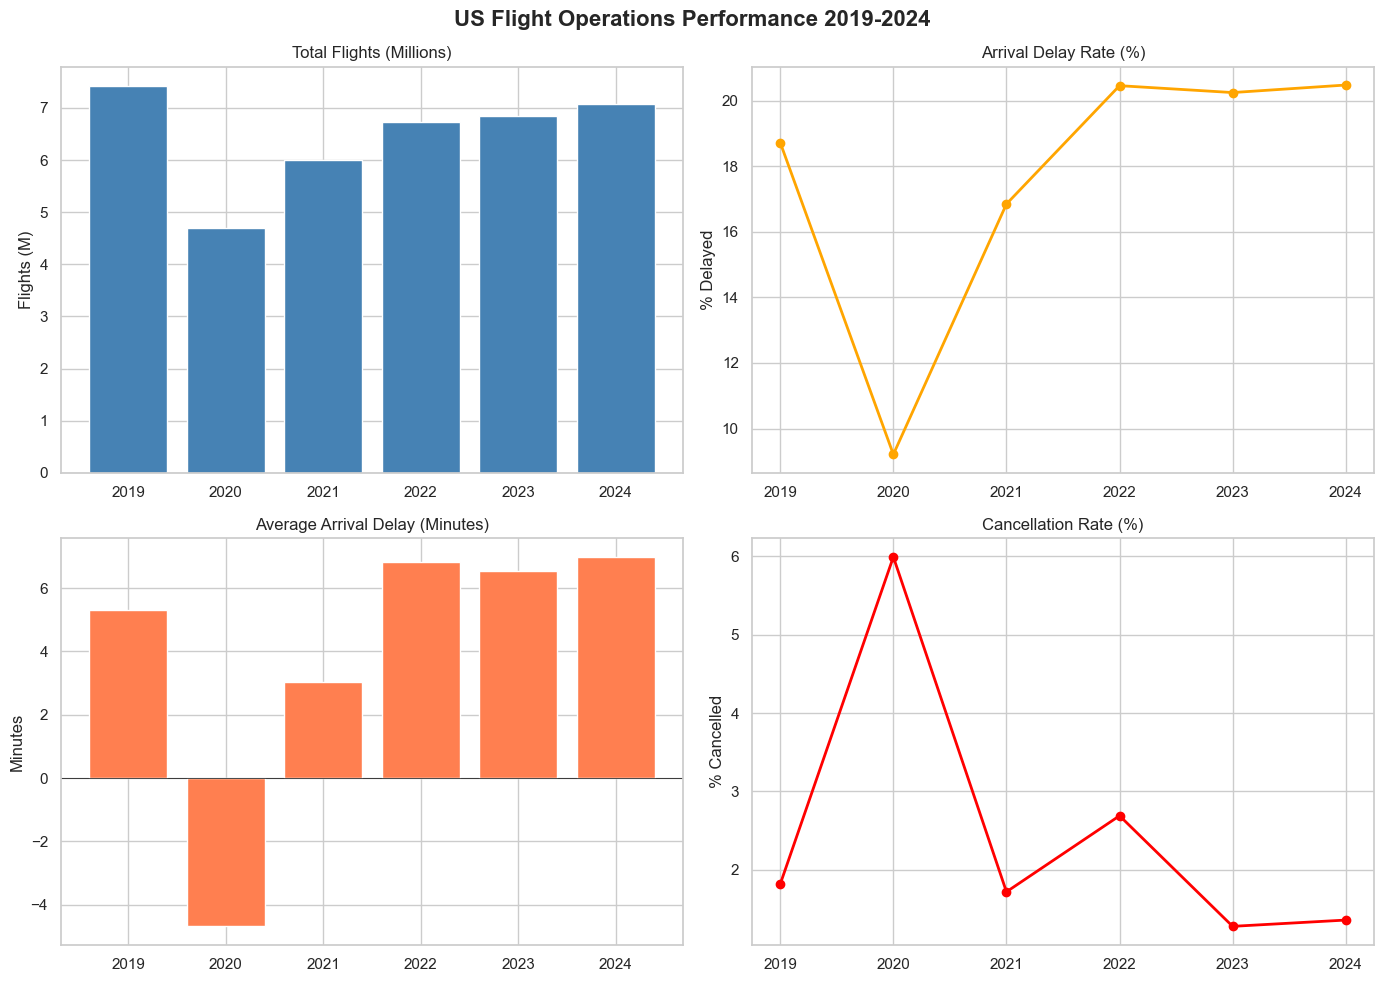

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('US Flight Operations Performance 2019-2024', fontsize=16, fontweight='bold')

# Total flights
axes[0,0].bar(yearly['Year'], yearly['total_flights']/1e6, color='steelblue')
axes[0,0].set_title('Total Flights (Millions)')
axes[0,0].set_ylabel('Flights (M)')

# Delay rate
axes[0,1].plot(yearly['Year'], yearly['delay_rate'], marker='o', color='orange', linewidth=2)
axes[0,1].set_title('Arrival Delay Rate (%)')
axes[0,1].set_ylabel('% Delayed')

# Average delay
axes[1,0].bar(yearly['Year'], yearly['avg_arr_delay'], color='coral')
axes[1,0].set_title('Average Arrival Delay (Minutes)')
axes[1,0].set_ylabel('Minutes')
axes[1,0].axhline(y=0, color='black', linewidth=0.5)

# Cancellation rate
axes[1,1].plot(yearly['Year'], yearly['cancel_rate'], marker='o', color='red', linewidth=2)
axes[1,1].set_title('Cancellation Rate (%)')
axes[1,1].set_ylabel('% Cancelled')

plt.tight_layout()
plt.savefig('../reports/yearly_performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

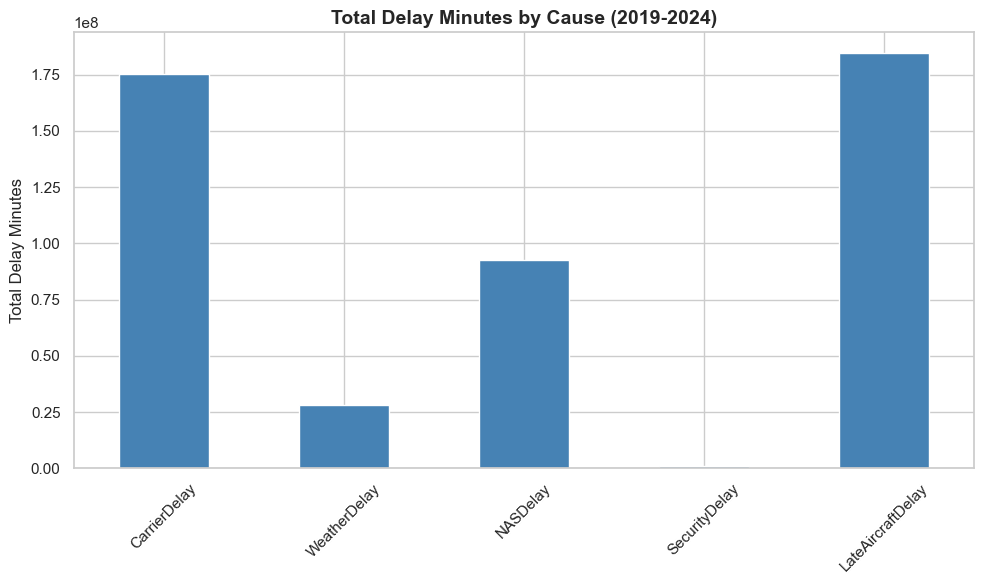


Delay cause breakdown (%):
CarrierDelay        36.41
WeatherDelay         5.84
NASDelay            19.21
SecurityDelay        0.21
LateAircraftDelay   38.33
dtype: float64


In [11]:
# Delay causes breakdown
delay_causes = df[['CarrierDelay', 'WeatherDelay', 'NASDelay', 
                    'SecurityDelay', 'LateAircraftDelay']].sum()

delay_causes.plot(kind='bar', figsize=(10, 6), color='steelblue')
plt.title('Total Delay Minutes by Cause (2019-2024)', fontsize=14, fontweight='bold')
plt.ylabel('Total Delay Minutes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/delay_causes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDelay cause breakdown (%):")
print((delay_causes / delay_causes.sum() * 100).round(2))

In [13]:
# Worst performing carriers
carrier_perf = df.groupby('Reporting_Airline').agg(
    total_flights=('ArrDel15', 'count'),
    delay_rate=('ArrDel15', 'mean'),
    avg_delay=('ArrDelay', 'mean')
).reset_index()

carrier_perf['delay_rate'] = (carrier_perf['delay_rate'] * 100).round(2)
carrier_perf['avg_delay'] = carrier_perf['avg_delay'].round(2)
carrier_perf = carrier_perf.sort_values('delay_rate', ascending=False)

print(carrier_perf.to_string(index=False))

Reporting_Airline  total_flights  delay_rate  avg_delay
               B6        1432468       26.01      11.81
               F9         905508       25.93      11.45
               G4         669301       24.00      11.58
               NK        1288682       21.99       7.81
               EV         186818       20.53       9.39
               AA        5051963       20.52       8.14
               WN        7554895       18.87       3.45
               UA        3500100       18.58       4.79
               AS        1311544       18.38       1.62
               YV         638674       18.20       7.38
               MQ        1549487       17.51       3.67
               OH        1341094       17.39       4.75
               OO        4340280       16.01       4.48
               HA         418209       15.78       3.83
               YX        1795227       14.65      -0.29
               DL        5208417       14.41       1.19
               QX         200419       14.31    

In [14]:
airline_names = {
    'AA': 'American Airlines',
    'AS': 'Alaska Airlines',
    'B6': 'JetBlue Airways',
    'DL': 'Delta Air Lines',
    'EV': 'ExpressJet',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air',
    'NK': 'Spirit Airlines',
    'OH': 'PSA Airlines',
    'OO': 'SkyWest Airlines',
    'QX': 'Horizon Air',
    'UA': 'United Airlines',
    'WN': 'Southwest Airlines',
    'YV': 'Mesa Airlines',
    'YX': 'Republic Airways',
    '9E': 'Endeavor Air'
}

carrier_perf['Airline_Name'] = carrier_perf['Reporting_Airline'].map(airline_names)
print(carrier_perf[['Airline_Name', 'Reporting_Airline', 'total_flights', 'delay_rate', 'avg_delay']].to_string(index=False))

      Airline_Name Reporting_Airline  total_flights  delay_rate  avg_delay
   JetBlue Airways                B6        1432468       26.01      11.81
 Frontier Airlines                F9         905508       25.93      11.45
     Allegiant Air                G4         669301       24.00      11.58
   Spirit Airlines                NK        1288682       21.99       7.81
        ExpressJet                EV         186818       20.53       9.39
 American Airlines                AA        5051963       20.52       8.14
Southwest Airlines                WN        7554895       18.87       3.45
   United Airlines                UA        3500100       18.58       4.79
   Alaska Airlines                AS        1311544       18.38       1.62
     Mesa Airlines                YV         638674       18.20       7.38
         Envoy Air                MQ        1549487       17.51       3.67
      PSA Airlines                OH        1341094       17.39       4.75
  SkyWest Airlines       

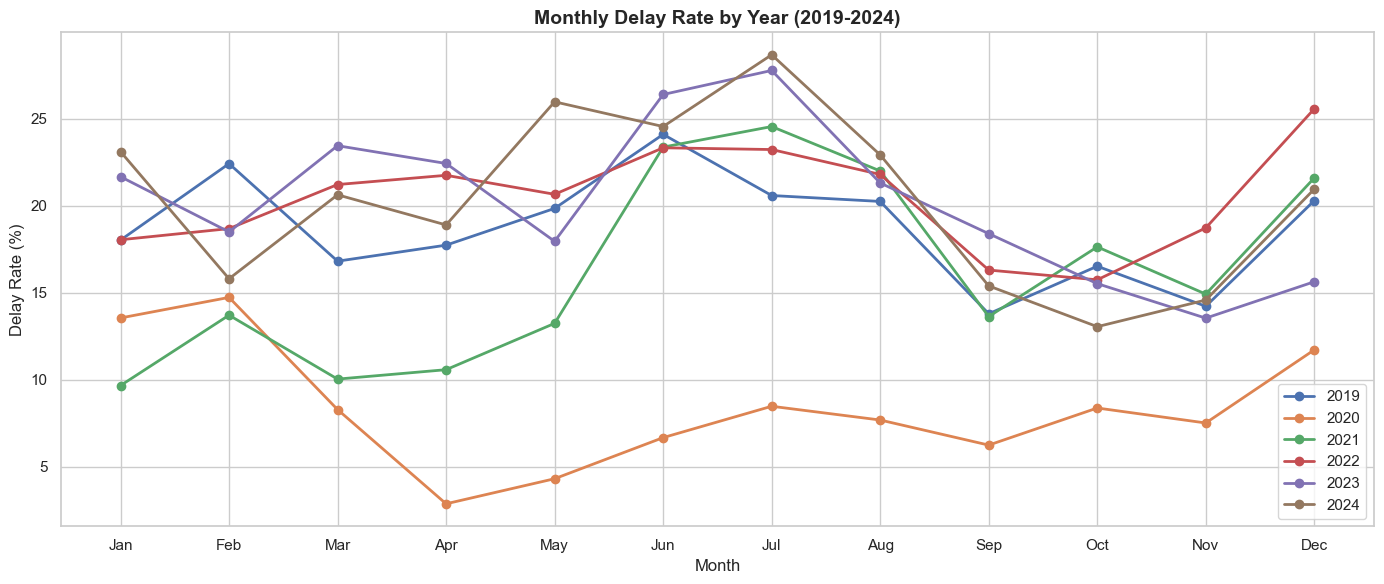

In [15]:
# Seasonal delay patterns
monthly = df.groupby(['Year', 'Month']).agg(
    total_flights=('ArrDel15', 'count'),
    delay_rate=('ArrDel15', 'mean'),
    avg_delay=('ArrDelay', 'mean')
).reset_index()

monthly['delay_rate'] = (monthly['delay_rate'] * 100).round(2)

# Plot
plt.figure(figsize=(14, 6))
for year in monthly['Year'].unique():
    year_data = monthly[monthly['Year'] == year]
    plt.plot(year_data['Month'], year_data['delay_rate'], 
             marker='o', label=str(year), linewidth=2)

plt.title('Monthly Delay Rate by Year (2019-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.savefig('../reports/seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Worst performing origin airports
airport_perf = df.groupby(['Origin', 'OriginCityName', 'OriginState']).agg(
    total_flights=('ArrDel15', 'count'),
    delay_rate=('ArrDel15', 'mean'),
    avg_delay=('ArrDelay', 'mean')
).reset_index()

airport_perf['delay_rate'] = (airport_perf['delay_rate'] * 100).round(2)
airport_perf['avg_delay'] = airport_perf['avg_delay'].round(2)

# Filter to airports with meaningful volume (at least 50k flights)
airport_perf = airport_perf[airport_perf['total_flights'] >= 50000]
airport_perf = airport_perf.sort_values('delay_rate', ascending=False)

print("=== WORST PERFORMING AIRPORTS ===")
print(airport_perf.head(15)[['Origin', 'OriginCityName', 'OriginState', 
                               'total_flights', 'delay_rate', 'avg_delay']].to_string(index=False))

print("\n=== BEST PERFORMING AIRPORTS ===")
print(airport_perf.sort_values('delay_rate', ascending=True).head(15)[
    ['Origin', 'OriginCityName', 'OriginState', 
     'total_flights', 'delay_rate', 'avg_delay']].to_string(index=False))

=== WORST PERFORMING AIRPORTS ===
Origin                 OriginCityName OriginState  total_flights  delay_rate  avg_delay
   FLL            Fort Lauderdale, FL          FL         516304       23.16       9.21
   MIA                      Miami, FL          FL         557389       22.96       9.41
   MCO                    Orlando, FL          FL         842469       22.90       9.64
   SJU                   San Juan, PR          PR         174406       22.64      10.67
   EWR                     Newark, NJ          NJ         692812       22.37       7.20
   SFB                    Sanford, FL          FL          57192       21.97       8.89
   DFW          Dallas/Fort Worth, TX          TX        1686117       21.84       8.93
   DEN                     Denver, CO          CO        1580935       21.77       7.06
   MDW                    Chicago, IL          IL         450203       21.54       5.14
   BWI                  Baltimore, MD          MD         533069       21.37       5.3